# FlightsData — Flight Fare Exploratory data analysis

A Jupyter notebook that loads, explores, and analyzes the Flight Fare Prediction dataset (Kaggle: nikhilmittal/flight-fare-prediction-mh)

## 1. Import Required Libraries
Import the necessary libraries including pandas for data manipulation, numpy for numerical operations, matplotlib and seaborn for data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Required for reading Excel files


## 2. Load the Flights Dataset
Load the Flight Fare Prediction dataset from the local `data/` folder into a pandas DataFrame.

In [2]:
# Load the Flight Fare Prediction dataset
df = pd.read_excel("data/Data_Train.xlsx")
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded successfully with 10683 rows and 11 columns.


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


## 3. Inspect the Dataset
Examine the first few rows, shape, data types, and summary statistics of the dataset using `head()`, `info()`, `describe()`, and `shape`.

In [3]:
# Shape of the dataset
print("Shape:", df.shape)
print()

# Data types and non-null counts
print("--- Dataset Info ---")
df.info()
print()

# Summary statistics
print("--- Summary Statistics ---")
df.describe()

Shape: (10683, 11)

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB

--- Summary Statistics ---


,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


## 4. Data Cleaning and Preprocessing
Handle missing values, convert data types where necessary (e.g., dates), and drop or fill null entries to prepare the data for analysis.

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print()

# Drop rows with missing values
df = df.dropna()
print(f"After cleaning: {df.shape[0]} rows, {df.shape[1]} columns")

# Convert Date_of_Journey to datetime
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df['Journey_Month'] = df['Date_of_Journey'].dt.month
df['Journey_Day'] = df['Date_of_Journey'].dt.day

# Extract duration in minutes
def parse_duration(duration):
    total_min = 0
    if 'h' in duration:
        total_min += int(duration.split('h')[0].strip()) * 60
        duration = duration.split('h')[1]
    if 'm' in duration:
        total_min += int(duration.split('m')[0].strip())
    return total_min

df['Duration_minutes'] = df['Duration'].apply(parse_duration)

# Convert Total_Stops to numeric
stops_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Total_Stops_num'] = df['Total_Stops'].map(stops_map)

df.head()

Missing values per column:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

After cleaning: 10682 rows, 11 columns


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Month,Journey_Day,Duration_minutes,Total_Stops_num
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,3,24,170,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,1,445,2
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,6,9,1140,2
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,5,12,325,1
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,3,1,285,1


## 5. Analyze Flight Fares by Airline
Group the data by airline and compute the average fare. Create a bar chart to compare fare performance across carriers.

C:\Users\ruchikar\AppData\Local\Temp\ipykernel_17260\3744920002.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_avg.values, y=airline_avg.index, palette="viridis")


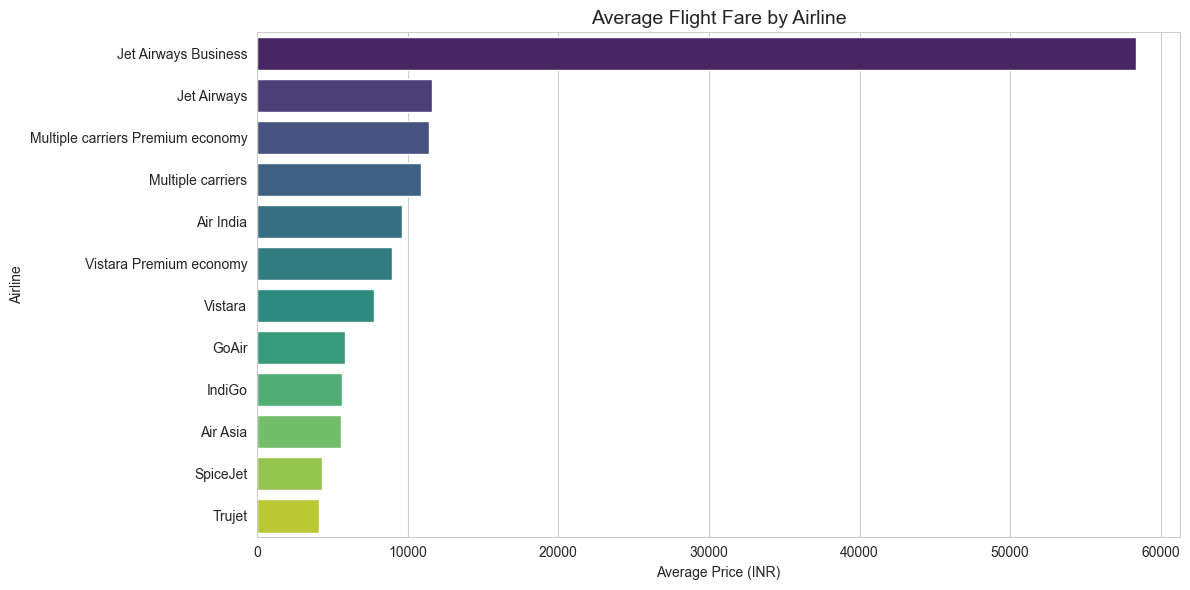

In [5]:
# Average fare by airline
airline_avg = df.groupby('Airline')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=airline_avg.values, y=airline_avg.index, palette="viridis")
plt.title("Average Flight Fare by Airline", fontsize=14)
plt.xlabel("Average Price (INR)")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()

## 6. Analyze Flights by Month
Aggregate the number of flights by month to identify seasonal patterns. Plot a bar chart showing monthly flight volume.

C:\Users\ruchikar\AppData\Local\Temp\ipykernel_17260\1738922942.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[calendar.month_abbr[m] for m in monthly_counts.index], y=monthly_counts.values, palette="coolwarm")


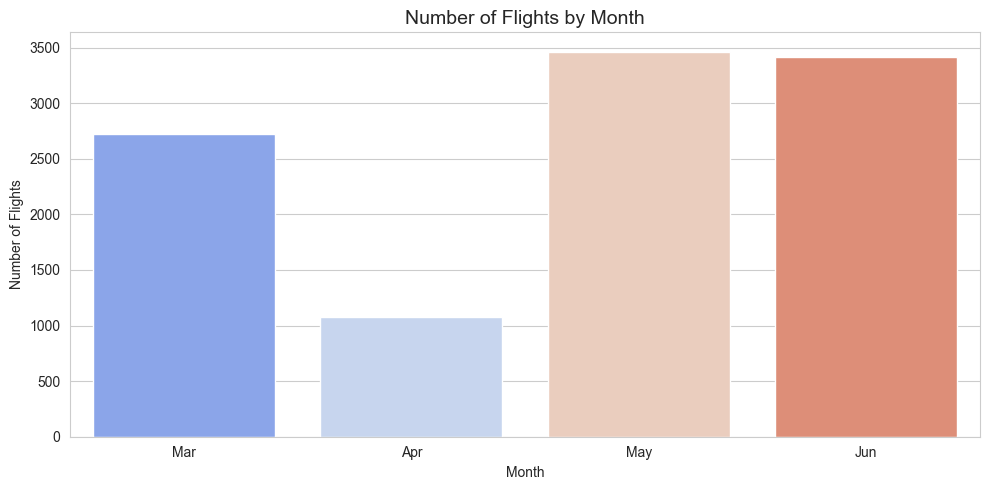

In [6]:
# Number of flights by month
import calendar
monthly_counts = df['Journey_Month'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=[calendar.month_abbr[m] for m in monthly_counts.index], y=monthly_counts.values, palette="coolwarm")
plt.title("Number of Flights by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

## 7. Visualize Fare Distribution and Trends
Create a histogram and boxplot showing the distribution of flight fares, as well as fare variation by number of stops.

C:\Users\ruchikar\AppData\Local\Temp\ipykernel_17260\2995225690.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Total_Stops', y='Price', data=df, order=['non-stop', '1 stop', '2 stops', '3 stops', '4 stops'], palette="Set2", ax=axes[1])


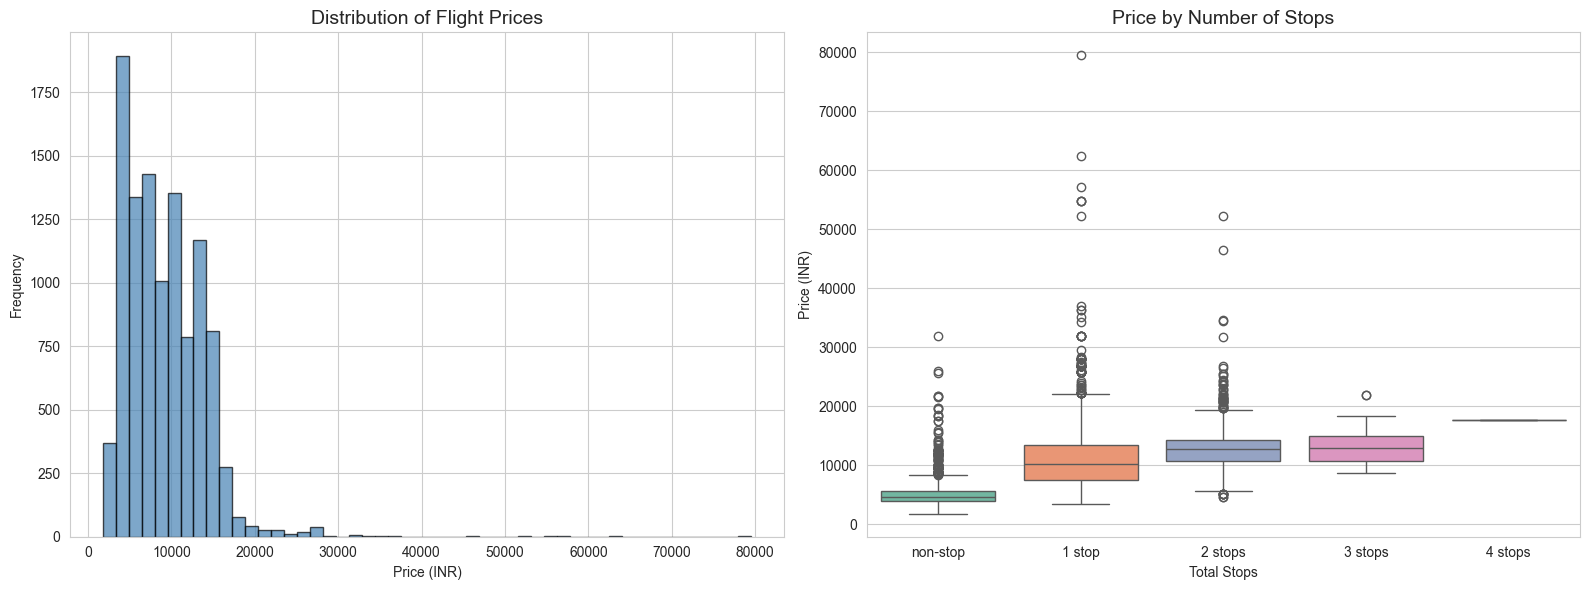

In [7]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Distribution of Flight Prices", fontsize=14)
axes[0].set_xlabel("Price (INR)")
axes[0].set_ylabel("Frequency")

# Boxplot by number of stops
sns.boxplot(x='Total_Stops', y='Price', data=df, order=['non-stop', '1 stop', '2 stops', '3 stops', '4 stops'], palette="Set2", ax=axes[1])
axes[1].set_title("Price by Number of Stops", fontsize=14)
axes[1].set_xlabel("Total Stops")
axes[1].set_ylabel("Price (INR)")

plt.tight_layout()
plt.show()

## 8. Correlation Analysis Between Numeric Features
Compute the correlation matrix for numeric columns and visualize it using a seaborn heatmap to identify relationships between variables.

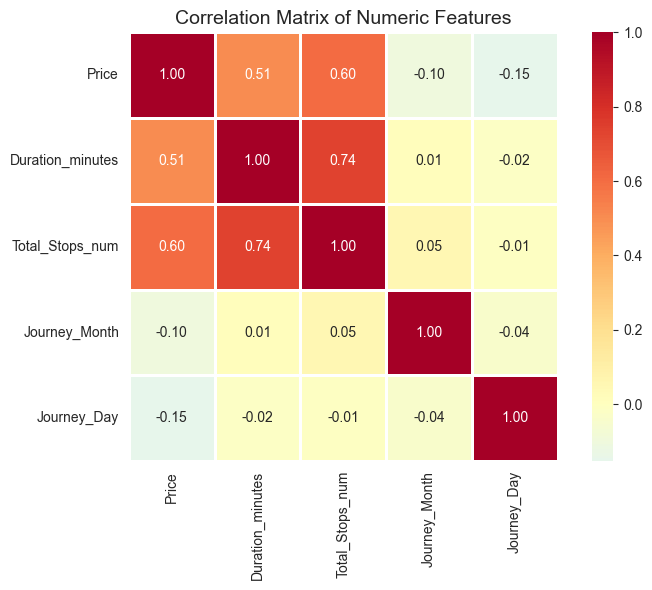

In [8]:
# Correlation matrix for numeric columns
numeric_df = df[['Price', 'Duration_minutes', 'Total_Stops_num', 'Journey_Month', 'Journey_Day']].dropna()
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="RdYlBu_r", center=0,
            fmt=".2f", square=True, linewidths=1)
plt.title("Correlation Matrix of Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Top Routes by Number of Flights
Identify the most popular flight routes (Source → Destination) by counting flights per route, and display the top results in a horizontal bar chart.

C:\Users\ruchikar\AppData\Local\Temp\ipykernel_17260\598474059.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_routes.values, y=top_routes.index, palette="magma")


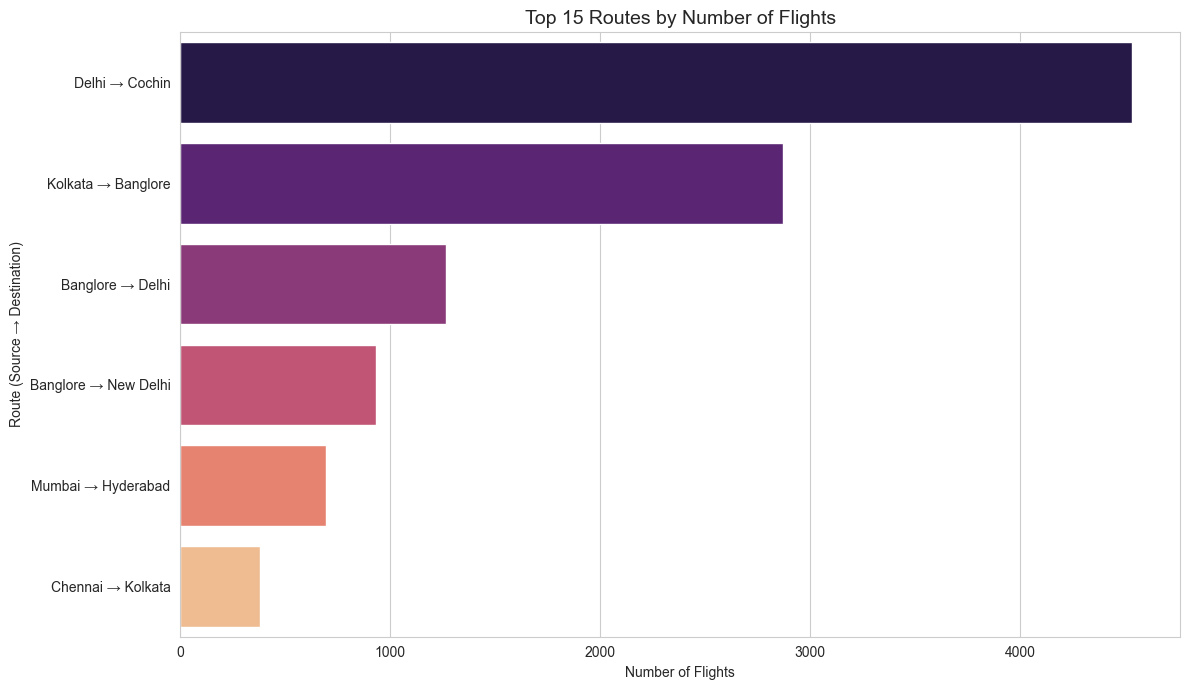

In [9]:
# Top routes by number of flights
df['Route_Label'] = df['Source'] + ' → ' + df['Destination']
top_routes = df['Route_Label'].value_counts().head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_routes.values, y=top_routes.index, palette="magma")
plt.title("Top 15 Routes by Number of Flights", fontsize=14)
plt.xlabel("Number of Flights")
plt.ylabel("Route (Source → Destination)")
plt.tight_layout()
plt.show()